In [ ]:
import pandas as pd
from src.preprocessing import fill_n_fix_ranges
import matplotlib.pyplot as plt
import numpy as np

In [2]:
TARGET_COLUMN_2 = "war_class"

dev_path_2 = "data/Problem_2/raw/WAR_class_dev.csv"
test_path_2 = "data/Problem_2/raw/WAR_class_test.csv"

WAR_class_dev_df = pd.read_csv(dev_path_2, na_values=["NaN", "N/A", ""])
WAR_class_dev_df = WAR_class_dev_df.drop(columns=['war_total'])
WAR_class_test_df = pd.read_csv(test_path_2, na_values=["NaN", "N/A", ""])
WAR_class_test_df = WAR_class_test_df.drop(columns=['war_total'])

In [ ]:
new_ranges_2 = {
    'raptor_total': (-16, 14),
    'pace_impact': (-2, 3), 
}

WAR_class_dev_arranged = fill_n_fix_ranges(
    data=WAR_class_dev_df, 
    target_col=TARGET_COLUMN_2,
    train=True,
    intervals=new_ranges_2,
)


In [4]:
from src.preprocessing import normalize_dataframe, calculate_stats_dict
from src.data_splitting import split_train_validation

In [5]:
RANDOM_STATE = 42

In [ ]:
dev_stats_dict_dt_Wc = calculate_stats_dict(WAR_class_dev_df) # el que tenga dropeada la columna

vWAR_class_test_arranged = fill_n_fix_ranges(
    data=WAR_class_test_df,
    target_col=TARGET_COLUMN_2,
    train=False,
    reference=WAR_class_dev_arranged,
    intervals=new_ranges_2,
    stats_dict=dev_stats_dict_dt_Wc,
    neighbors=5,
)

WAR_class_dev_arranged_norm_dt, dev_stats_dt_Wc = normalize_dataframe(WAR_class_dev_arranged, target_col=TARGET_COLUMN_2)
WAR_class_test_arranged_norm_dt, _ = normalize_dataframe(vWAR_class_test_arranged, train=False, stats_dict=dev_stats_dt_Wc, target_col=TARGET_COLUMN_2)


# dt - dev-test

X_test_dt_Wc = WAR_class_test_arranged_norm_dt.drop(columns=[TARGET_COLUMN_2])
y_test_dt_Wc = WAR_class_test_arranged_norm_dt[TARGET_COLUMN_2]

X_train_dt_Wc = WAR_class_dev_arranged_norm_dt.drop(columns=[TARGET_COLUMN_2])
y_train_dt_Wc = WAR_class_dev_arranged_norm_dt[TARGET_COLUMN_2]


In [7]:
from src.models import LDA, RandomForest, LogisticRegression
from src.metrics import f1_score_macro_multiclass, MulticlassMetrics

In [8]:
# WAR_class_train_trv, WAR_class_val_trv = split_train_validation(WAR_class_dev_df, seed=RANDOM_STATE)
# WAR_class_train_arranged = handle_missing_values(
#     data=WAR_class_train_trv, 
#     target_col=TARGET_COLUMN_2, 
#     train=True,
#     intervals=new_ranges_2
# )

# train_stats_dict_trv_Wc = calculate_stats_dict(WAR_class_train_arranged)

# WAR_class_val_arranged = handle_missing_values(
#     data=WAR_class_val_trv, 
#     target_col=TARGET_COLUMN_2, 
#     train=False, 
#     reference=WAR_class_train_arranged,
#     intervals=new_ranges_2, 
#     stats_dict=train_stats_dict_trv_Wc 
# )

# WAR_class_train_arranged_norm_trv, train_stats_trv_Wc = normalize_dataframe(WAR_class_train_arranged, target_col=TARGET_COLUMN_2)
# WAR_class_val_arranged_norm_trv, _ = normalize_dataframe(WAR_class_val_arranged, train=False, stats_dict=train_stats_trv_Wc, target_col=TARGET_COLUMN_2)

In [9]:
# X_train_trv_Wc = WAR_class_train_arranged_norm_trv.drop(columns=[TARGET_COLUMN_2])
# y_train_trv_Wc = WAR_class_train_arranged_norm_trv[TARGET_COLUMN_2]

# X_val_trv_Wc = WAR_class_val_arranged_norm_trv.drop(columns=[TARGET_COLUMN_2])
# y_val_trv_Wc = WAR_class_val_arranged_norm_trv[TARGET_COLUMN_2]

In [10]:
# # train with logistic regression
# lr_multiclass_trv = LogisticRegression(multiclass_strategy='multinomial')

# # Definir rango de lambda
# lambdas = np.logspace(0, 4, 100)
# f1_scores_lr_trv_Wc = []

# best_f1_lr_trv_Wc = -1
# best_model_lr_trv_Wc = None
# best_lambda_lr_Wc = None


# for l2 in lambdas:
#     lr_multiclass_trv = LogisticRegression(multiclass_strategy='multinomial', l2=l2)
#     lr_multiclass_trv.fit(X_train_trv_Wc, y_train_trv_Wc)

#     y_val_pred_lr_lambdas = lr_multiclass_trv.predict(X_val_trv_Wc)
#     f1 = f1_score_macro_multiclass(y_val_trv_Wc, y_val_pred_lr_lambdas)
#     f1_scores_lr_trv_Wc.append(f1)

#     if f1 > best_f1_lr_trv_Wc:
#         best_f1_lr_trv_Wc = f1
#         best_lambda_lr_Wc = l2
#         best_model_lr_trv_Wc = lr_multiclass_trv

# # # Graficar F1 Score vs Lambda
# # plt.figure()
# # plt.plot(lambdas, f1_scores_lr_trv_Wc)
# # plt.scatter(best_lambda_lr_Wc, best_f1_lr_trv_Wc, color='red', label='Mejor Lambda')
# # plt.xscale('log')
# # plt.xlabel("Lambda (Regularización L2)")
# # plt.ylabel("F1 Score (Macro)")
# # plt.title("Selección de Lambda usando F1 Score (Validación)")
# # plt.legend()
# # plt.grid(True)
# # plt.show()

# print(f"Mejor modelo encontrado con λ = {best_lambda_lr_Wc:.5f} (F1 Score = {best_f1_lr_trv_Wc:.4f})")
# y_val_pred_lr_trv_Wc = best_model_lr_trv_Wc.predict(X_val_trv_Wc)
# y_val_pred_proba_lr_trv_Wc = best_model_lr_trv_Wc.predict_proba(X_val_trv_Wc)


In [ ]:
from itertools import product


def run_grid_search(ModelClass, param_grid, X_train, y_train, X_val, y_val, metric_fn):
    """
    Ejecuta una búsqueda de grilla para encontrar los mejores hiperparámetros de un modelo.

    Parámetros:
        - ModelClass: clase del modelo (no instanciado)
        - param_grid: dict con lista de valores para cada hiperparámetro
        - X_train, y_train: datos de entrenamiento
        - X_val, y_val: datos de validación
        - metric_fn: función que recibe (y_true, y_pred) y devuelve el score

    Devuelve:
        - mejor modelo entrenado
        - mejor score
        - mejores hiperparámetros
    """
    best_score = -np.inf
    best_model = None
    best_params = {}

    # Generar combinaciones de hiperparámetros
    keys = list(param_grid.keys())
    for values in product(*param_grid.values()):
        params = dict(zip(keys, values))
        model = ModelClass(**params)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        score = metric_fn(y_val, y_pred)

        if score > best_score:
            best_score = score
            best_model = model
            best_params = params

    return best_model, best_score, best_params


In [ ]:
param_grid_lr = {
    'l2': [0.01, 0.1, 1, 10],
    'learning_rate': [0.0001, 0.001, 0.01, 0.1],
    'iterations': [300, 500, 1000, 1500],
    'multiclass_strategy': ['multinomial']
}

best_lr_model, best_f1_lr, best_params_lr = run_grid_search(
    LogisticRegression,
    param_grid_lr,
    X_train_dt_Wc, y_train_dt_Wc,
    X_test_dt_Wc, y_test_dt_Wc,
    metric_fn=lambda y_true, y_pred: MulticlassMetrics(y_true, y_pred, None).f1_score()
)


### Métricas de Evaluación para el conjunto de **Test** del set **WAR_class**

| Métrica   |   Valor |
|:----------|--------:|
| Accuracy  |  0.8927 |
| Precision |  0.8978 |
| Recall    |  0.9020 |
| F1 Score  |  0.8927 |
| AUC-ROC   |  0.9615 |
| AUC-PR    |  0.9211 |

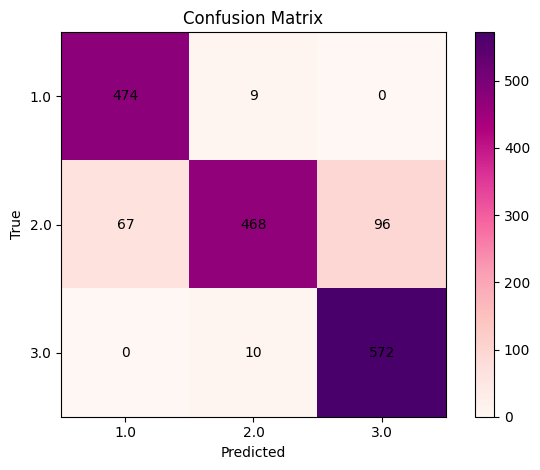

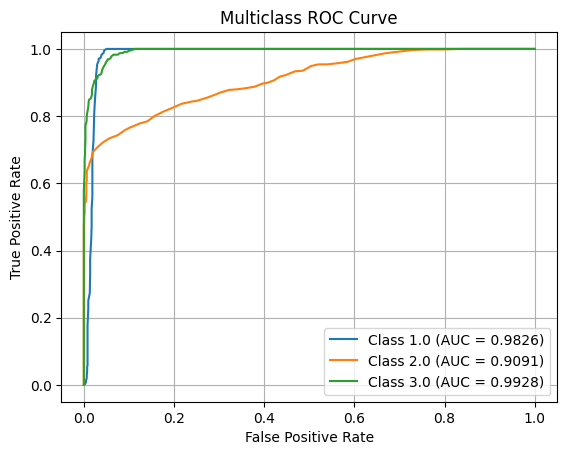

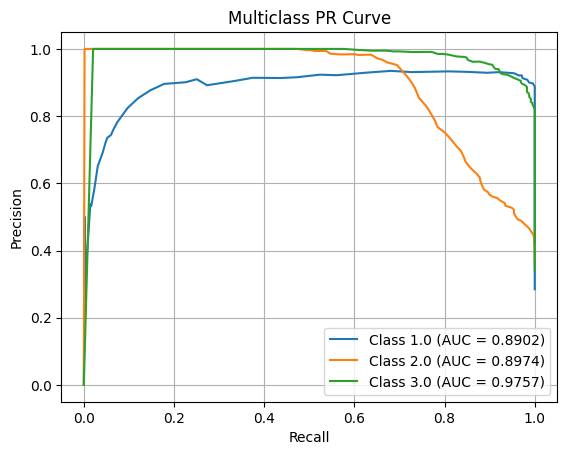

In [21]:
# Predecir sobre test
y_pred_lr_dt_best_model = best_lr_model.predict(X_test_dt_Wc)
y_proba_lr_dt_best_model = best_lr_model.predict_proba(X_test_dt_Wc)

# Instanciar métricas y reportar
metrics_lr_dt_best_model = MulticlassMetrics(y_test_dt_Wc, y_pred_lr_dt_best_model, y_proba_lr_dt_best_model)
metrics_lr_dt_best_model.report_metrics(dataset_name="WAR_class", set_type="Test")


In [ ]:
# param_grid_rf = {
#     'n_trees': [5, 10, 20],
#     'max_depth': [5, 10, None],
#     'min_samples': [2, 5]
# }

param_grid_rf = {
    'n_trees': [5, 10, 20, 50],
    'max_depth': [3, 5, 10, 15, None],
    'min_samples': [1, 2, 5, 10]
}

best_rf_model, best_f1_rf, best_params_rf = run_grid_search(
    RandomForest,
    param_grid_rf,
    X_train_dt_Wc, y_train_dt_Wc,
    X_test_dt_Wc, y_test_dt_Wc,
    metric_fn=lambda y_true, y_pred: MulticlassMetrics(y_true, y_pred, None).f1_score()
)


### Métricas de Evaluación para el conjunto de **Test** del set **WAR_class**

| Métrica   |   Valor |
|:----------|--------:|
| Accuracy  |  0.9670 |
| Precision |  0.9669 |
| Recall    |  0.9690 |
| F1 Score  |  0.9678 |
| AUC-ROC   |  0.9924 |
| AUC-PR    |  0.1777 |

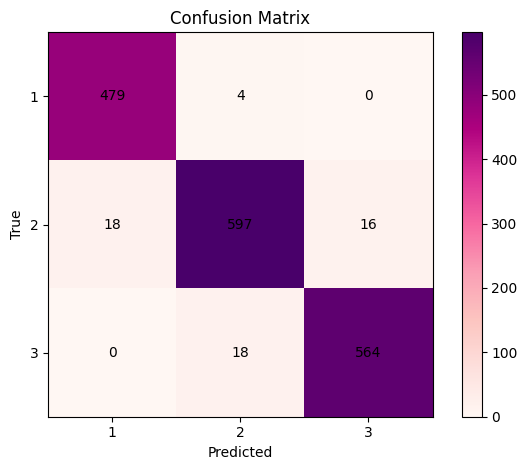

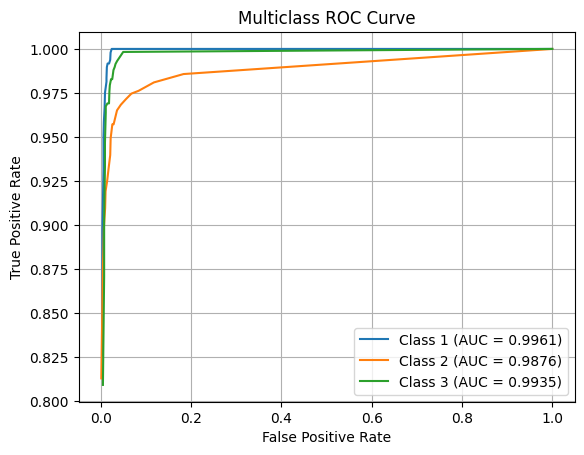

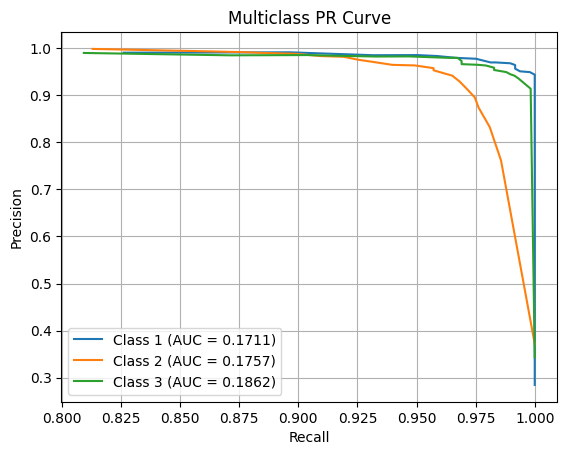

In [20]:
y_pred_rf_dt_best_model = best_rf_model.predict(X_test_dt_Wc)
y_proba_rf_dt_best_model = best_rf_model.predict_proba(X_test_dt_Wc)

metrics_rf_dt_best_model = MulticlassMetrics(y_test_dt_Wc, y_pred_rf_dt_best_model, y_proba_rf_dt_best_model)
metrics_rf_dt_best_model.report_metrics(dataset_name="WAR_class", set_type="Test")

In [14]:
# model_lr_trv_Wc = LogisticRegression(
#     multiclass_strategy='multinomial',
#     iterations=1350,
#     l2=best_lambda_lr_Wc,
# )
# model_lr_trv_Wc.fit(X_train_dt_Wc, y_train_dt_Wc)

# y_pred_lr_dt_Wc = model_lr_trv_Wc.predict(X_test_dt_Wc)
# y_pred_proba_lr_dt_Wc = model_lr_trv_Wc.predict_proba(X_test_dt_Wc)

# # y_scores_dt = model_lr_trv_Wc.predict_proba(X_test_dt_Wc)
# # y_pred_dt = (y_scores_dt >= 0.5).astype(int)

# print("\nEvaluación en conjunto de test:")

# binary_metrics_lr_dt = MulticlassMetrics(y_test_dt_Wc, y_pred_lr_dt_Wc, y_pred_proba_lr_dt_Wc)  # y_scores: probabilidades
# binary_metrics_lr_dt.report_metrics(dataset_name="WAR_class_dev", set_type="Test")


In [15]:
lda_dt = LDA()

lda_dt.fit(X_train_dt_Wc, y_train_dt_Wc)

y_pred_LDA_dt = lda_dt.predict(X_test_dt_Wc)
y_pred_prob_LDA_dt = lda_dt.predict_proba(X_test_dt_Wc)

### Métricas de Evaluación para el conjunto de **Test** del set **WAR_class**

| Métrica   |   Valor |
|:----------|--------:|
| Accuracy  |  0.9039 |
| Precision |  0.9095 |
| Recall    |  0.9131 |
| F1 Score  |  0.9029 |
| AUC-ROC   |  0.9732 |
| AUC-PR    |  0.8656 |

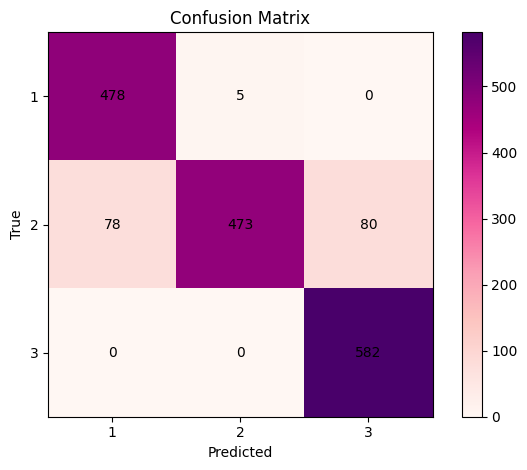

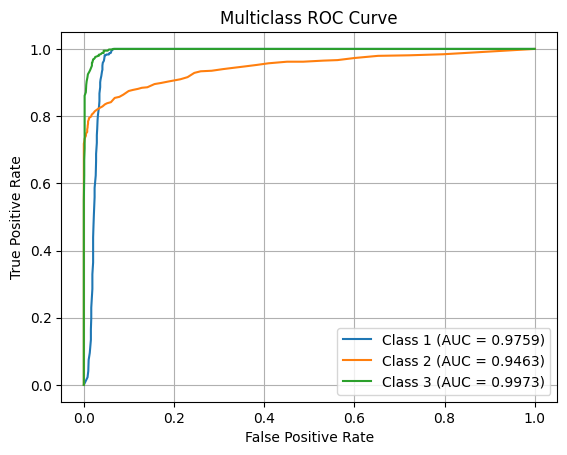

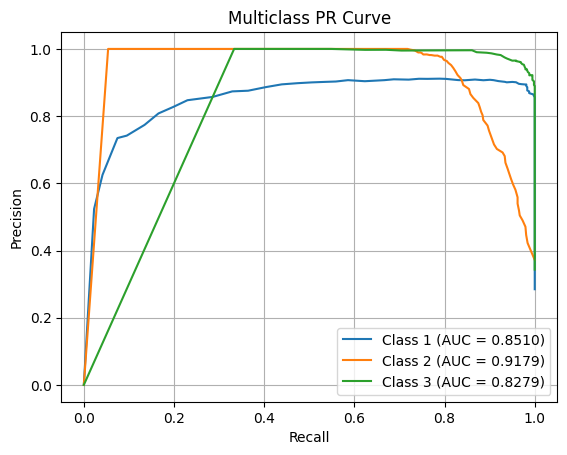

In [16]:
multiclass_metrics_LDA_dt = MulticlassMetrics(y_test_dt_Wc, y_pred_LDA_dt, y_pred_prob_LDA_dt)
multiclass_metrics_LDA_dt.report_metrics(dataset_name="WAR_class", set_type="Test")

In [17]:
WAR_class_dev_df = pd.read_csv(dev_path_2, na_values=["NaN", "N/A", ""])
WAR_class_dev_df = WAR_class_dev_df.drop(columns=['war_total'])
WAR_class_test_df = pd.read_csv(test_path_2, na_values=["NaN", "N/A", ""])
WAR_class_test_df = WAR_class_test_df.drop(columns=['war_total'])



In [18]:
X_test_dt_rf = WAR_class_test_df.drop(columns=[TARGET_COLUMN_2])
y_test_dt_rf = WAR_class_test_df[TARGET_COLUMN_2]

X_train_dt_rf = WAR_class_dev_df.drop(columns=[TARGET_COLUMN_2])
y_train_dt_rf = WAR_class_dev_df[TARGET_COLUMN_2]

In [19]:
rf_dt = RandomForest()

rf_dt.fit(X_train_dt_rf, y_train_dt_rf)

y_pred_rf_dt = rf_dt.predict(X_test_dt_rf)
y_pred_prob_rf_dt = rf_dt.predict_proba(y_test_dt_rf)

IndexError: invalid index to scalar variable.

In [ ]:
multiclass_metrics_rf_dt = MulticlassMetrics(y_test_dt_Wc, y_pred_rf_dt, y_pred_prob_rf_dt)
multiclass_metrics_rf_dt.report_metrics(dataset_name="WAR_class", set_type="Test")